<a href="https://colab.research.google.com/github/dewmindi/autoGrader/blob/dewmindi-do-2/AutoGrader.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import csv
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from collections import Counter

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:

uploaded = files.upload()


data = []
with open('question4.csv', mode='r') as file:
    csvFile = csv.reader(file)
    header = next(csvFile)
    for lines in csvFile:
        data.append(lines)

Saving question4.csv to question4 (1).csv


In [ ]:
answer_index =0

def count_words(text):
    cleaned_text = text.replace(",", "").replace(".", "").strip()
    return len(word_tokenize(cleaned_text))

def count_unique_words(text):
    cleaned_text = text.replace(",", "").replace(".", "").strip()
    return len(set(word_tokenize(cleaned_text)))

def count_stop_words(text):
    cleaned_text = text.replace(",", "").replace(".", "").strip()
    stop_words_set = set(stopwords.words('english'))
    return sum(1 for word in word_tokenize(text) if word in stop_words_set)

def count_non_stop_words(text):
    cleaned_text = text.replace(",", "").replace(".", "").strip()
    return count_words(text) - count_stop_words(text)

def count_sentences(text):
    cleaned_text = text.replace(",", "").replace(".", "").strip()
    return len(sent_tokenize(text))

def count_long_words(text, length=5):
    cleaned_text = text.replace(",", "").replace(".", "").strip()
    return sum(1 for word in word_tokenize(text) if len(word) > length)

def unique_words_with_frequency(text):
    tokenized = word_tokenize(text)
    return dict(Counter(tokenized))


In [ ]:
processed_data = []
header = ['Answer', 'Words', 'Unique_Words', 'Stop_Words',
          'Non_Stop_Words', 'Sentences', 'Long_Words', 'Word_Frequencies']
processed_data.append(header)

for row in data:
    Answer = row[answer_index].lower().strip()
    Words = count_words(Answer)
    no_of_unique_words = count_unique_words(Answer)
    no_of_stop_words = count_stop_words(Answer)
    no_of_non_stop_words = count_non_stop_words(Answer)
    no_of_sentences = count_sentences(Answer)
    no_of_long_words = count_long_words(Answer)
    Word_Frequencies = unique_words_with_frequency(Answer)

    processed_data.append([Answer, Words, no_of_unique_words, no_of_stop_words,
                           no_of_non_stop_words, no_of_sentences, no_of_long_words, Word_Frequencies])

In [ ]:
import pandas as pd

for row in processed_data[1:]:
    row[-1] = str(row[-1])

output_file = "processed_dataset_question4.csv"
df = pd.DataFrame(processed_data[1:], columns=processed_data[0])
df.to_csv(output_file, index=False)

from google.colab import files
files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
import pandas as pd

# Upload multiple CSV files
print("Please select multiple CSV files to upload:")
uploaded = files.upload()

# Initialize an empty list to store DataFrames
dataframes = []

# Loop through the uploaded files and read each into a DataFrame
for file_name in uploaded.keys():
    df = pd.read_csv(file_name)  # Read CSV file
    dataframes.append(df)        # Append DataFrame to the list

# Combine all DataFrames into one
combined_df = pd.concat(dataframes, ignore_index=True)

# Add the "Rating" column
combined_df['Rating'] = [(i % 10) + 1 for i in range(len(combined_df))]

# Save the combined DataFrame to a new CSV file
output_file = "AutoGrader_DataSet.csv"
combined_df.to_csv(output_file, index=False)

print(f"Combined CSV file with ratings saved as {output_file}")

# Provide a download link for the combined CSV
files.download(output_file)


Please select multiple CSV files to upload:


Saving processed_dataset_question1.csv to processed_dataset_question1 (2).csv
Saving processed_dataset_question2.csv to processed_dataset_question2 (2).csv
Saving processed_dataset_question3.csv to processed_dataset_question3 (2).csv
Saving processed_dataset_question4.csv to processed_dataset_question4 (2).csv
Saving processed_dataset_question5.csv to processed_dataset_question5 (2).csv
Combined CSV file with ratings saved as AutoGrader_DataSet.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import csv
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from google.colab import files  # For uploading and downloading files in Colab

# Step 1: Upload the CSV file
print("Please upload your dataset (CSV format):")
uploaded = files.upload()

# Get the file name of the uploaded file
file_name = list(uploaded.keys())[0]

# Read the uploaded CSV file
data = []
with open(file_name, mode='r') as file:
    csvFile = csv.reader(file)
    header = next(csvFile)
    for lines in csvFile:
        data.append(lines)

# Convert the data to a DataFrame
df = pd.DataFrame(data, columns=header)

# Step 2: Preprocess the text
def preprocess_text(text):
    """Preprocess text by converting to lowercase and stripping whitespace."""
    return str(text).lower().strip()

# Apply preprocessing to both columns
df['Real Answer'] = df['Real Answer'].apply(preprocess_text)
df['Answer'] = df['Answer'].apply(preprocess_text)

# Step 3: Compute TF-IDF vectors
# Initialize the TF-IDF vectorizer
vectorizer = TfidfVectorizer()

# Combine all text for a consistent vocabulary
all_text = pd.concat([df['Real Answer'], df['Answer']], axis=0)

# Fit and transform the text data
vectorizer.fit(all_text)
real_answer_tfidf = vectorizer.transform(df['Real Answer'])
answer_tfidf = vectorizer.transform(df['Answer'])

# Step 4: Compute Cosine Similarity
# Compute similarity for each pair of Real Answer and Answer
similarity_scores = [
    cosine_similarity(real_answer_tfidf[i], answer_tfidf[i])[0][0]
    for i in range(len(df))
]

# Step 5: Normalize the Rating and Adjust Similarity
# Assuming the rating is in the range [1, 10]
df['Rating Normalized'] = df['Rating'].astype(float) / 10.0

# Adjust similarity score by normalizing the rating
df['Adjusted Similarity'] = [
    similarity_scores[i] * df['Rating Normalized'][i]
    for i in range(len(df))
]

# Step 6: Save the updated dataset
output_file_name = "AutoGrader_DataSet_with_Adjusted_Similarity.csv"
df.to_csv(output_file_name, index=False)

print(f"Updated dataset with adjusted similarity scores saved to: {output_file_name}")

# Step 7: Download the updated dataset
files.download(output_file_name)


Please upload your dataset (CSV format):


Saving AutoGrader_DataSet_WithAnswers.csv to AutoGrader_DataSet_WithAnswers (1).csv
Updated dataset with adjusted similarity scores saved to: AutoGrader_DataSet_with_Adjusted_Similarity.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import csv
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from google.colab import files  # For uploading and downloading files in Colab

# Step 1: Upload the CSV file
print("Please upload your dataset (CSV format):")
uploaded = files.upload()

# Get the file name of the uploaded file
file_name = list(uploaded.keys())[0]

# Read the uploaded CSV file
data = []
with open(file_name, mode='r') as file:
    csvFile = csv.reader(file)
    header = next(csvFile)
    for lines in csvFile:
        data.append(lines)

# Convert the data to a DataFrame
df = pd.DataFrame(data, columns=header)

# Step 2: Load the pre-trained Sentence-BERT model
model = SentenceTransformer('all-MiniLM-L6-v2')  # You can use other models if needed

# Step 3: Generate embeddings for Real Answer and Answer
df['Real Answer Embedding'] = df['Real Answer'].apply(lambda x: model.encode(str(x)))
df['Answer Embedding'] = df['Answer'].apply(lambda x: model.encode(str(x)))

# Step 4: Compute Cosine Similarity Between the Embeddings
similarity_scores = [
    cosine_similarity([df['Real Answer Embedding'][i]], [df['Answer Embedding'][i]])[0][0]
    for i in range(len(df))
]

# Step 5: Normalize the Rating (If rating exists in your dataset)
df['Rating Normalized'] = df['Rating'].astype(float) / 10.0

# Step 6: Adjust Similarity Based on Rating
df['Adjusted Similarity'] = [
    similarity_scores[i] * df['Rating Normalized'][i]
    for i in range(len(df))
]

# Step 7: Save the updated dataset with semantic similarity scores
output_file_name = "AutoGrader_DataSet_with_Semantic_Similarity.csv"
df.to_csv(output_file_name, index=False)

print(f"Updated dataset with adjusted semantic similarity scores saved to: {output_file_name}")

# Step 8: Download the updated dataset
files.download(output_file_name)


Please upload your dataset (CSV format):


Saving AutoGrader_DataSet_WithAnswers.csv to AutoGrader_DataSet_WithAnswers (2).csv


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Updated dataset with adjusted semantic similarity scores saved to: AutoGrader_DataSet_with_Semantic_Similarity.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saving DataLatest.csv to DataLatest (2).csv
First 5 rows of the dataset:
                                         Real Answer  \
0  Supply Chain Management (SCM) is the process o...   
1  Supply Chain Management (SCM) is the process o...   
2  Supply Chain Management (SCM) is the process o...   
3  Supply Chain Management (SCM) is the process o...   
4  Supply Chain Management (SCM) is the process o...   

                                              Answer  Words  Unique_Words  \
0  supply chain management is about moving things...     17            17   
1  supply chain management is managing the supply...     15            14   
2  supply chain management is making sure goods g...     16            16   
3  supply chain management means managing the pro...     20            19   
4  supply chain management is the coordination of...     31            28   

   Stop_Words  Non_Stop_Words  Sentences  Long_Words  \
0           6              11          2           8   
1           4  

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

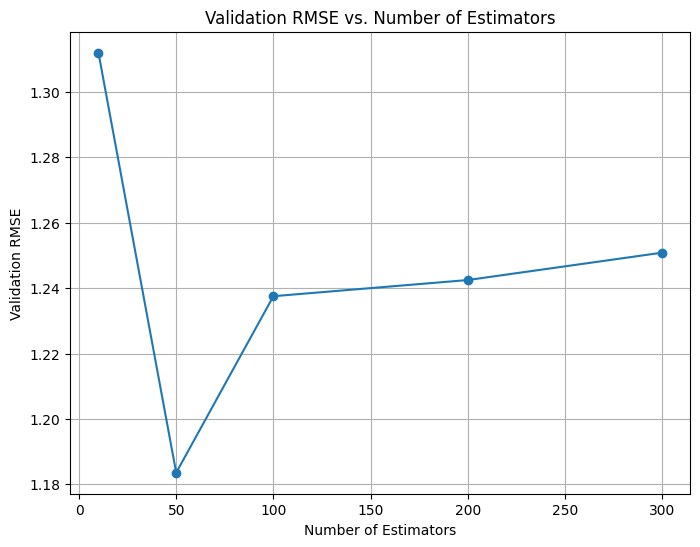

Predictions for the new test data:
Sample 1: Predicted Rating = 8.04
Sample 2: Predicted Rating = 1.08
Sample 3: Predicted Rating = 7.87
Sample 4: Predicted Rating = 9.74
Sample 5: Predicted Rating = 5.81
Sample 6: Predicted Rating = 5.56
Sample 7: Predicted Rating = 7.41
Sample 8: Predicted Rating = 2.45
Sample 9: Predicted Rating = 2.49
Sample 10: Predicted Rating = 1.29
Sample 11: Predicted Rating = 5.96
Sample 12: Predicted Rating = 7.65
Sample 13: Predicted Rating = 4.84
Sample 14: Predicted Rating = 6.02
Sample 15: Predicted Rating = 8.93
Sample 16: Predicted Rating = 6.20
Sample 17: Predicted Rating = 5.99
Sample 18: Predicted Rating = 6.11
Sample 19: Predicted Rating = 6.59
Sample 20: Predicted Rating = 5.08
Sample 21: Predicted Rating = 9.80


In [7]:
# Step 1: Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib
from google.colab import files

# Step 2: Upload the CSV File
uploaded = files.upload()

# Load the uploaded CSV file into a DataFrame
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# Step 3: Inspect the Dataset
print("First 5 rows of the dataset:")
print(df.head())
print("\nDataset Info:")
print(df.info())

# Step 4: Preprocessing the Data
# Check for missing values and fill them (if necessary)
if df.isnull().sum().sum() > 0:
    print("Missing values detected. Filling with mean values.")
    df.fillna(df.mean(), inplace=True)

# Normalize specific columns if required (Optional)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
columns_to_scale = ['Adjusted Similarity', 'Words', 'Unique_Words', 'Stop_Words', 'Non_Stop_Words', 'Sentences', 'Long_Words']
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

# Define Features and Target
features = ['Words', 'Unique_Words', 'Stop_Words', 'Non_Stop_Words', 'Sentences', 'Long_Words', 'Adjusted Similarity']
target = 'Rating'

X = df[features]
y = df[target]

# Step 5: Split the Dataset
# Use 150 rows for training, testing, and validation; 21 rows for a separate test set
X_train_test, X_new_test, y_train_test, y_new_test = train_test_split(X, y, test_size=20/170, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_train_test, y_train_test, test_size=0.2, random_state=42)

print(f"Training data: {X_train.shape}")
print(f"Validation/Test data: {X_test.shape}")
print(f"New test data: {X_new_test.shape}")

# Step 6: Train the Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit the model
rf_model.fit(X_train, y_train)

# Step 7: Evaluate the Model
# Predict on validation/test data
y_test_pred = rf_model.predict(X_test)

# Calculate metrics
rmse = mean_squared_error(y_test, y_test_pred) ** 0.5 # Calculate RMSE using the square root of MSE
r2 = r2_score(y_test, y_test_pred)

print(f"Validation/Test RMSE: {rmse}")
print(f"Validation/Test R² Score: {r2}")

# Step 8: Evaluate on the New Test Set
y_new_test_pred = rf_model.predict(X_new_test)

# Calculate metrics for the new test set
#new_rmse = mean_squared_error(y_new_test, y_new_test_pred, squared=False)
#new_r2 = r2_score(y_new_test, y_new_test_pred)

# Calculate metrics for the new test set
new_rmse = mean_squared_error(y_new_test, y_new_test_pred) ** 0.5 # Calculate RMSE using the square root of MSE
new_r2 = r2_score(y_new_test, y_new_test_pred)

print(f"New Test Set RMSE: {new_rmse}")
print(f"New Test Set R² Score: {new_r2}")

# Step 9: Save the Model
joblib.dump(rf_model, 'random_forest_model.pkl')
print("Model saved as random_forest_model.pkl")

# Optional: Download the model file
files.download('random_forest_model.pkl')

# Step 10: Visualize Accuracy over Epochs (Simulating Epochs)
# Simulate "epochs" by varying the number of estimators in the Random Forest
import matplotlib.pyplot as plt

estimators = [10, 50, 100, 200, 300]
rmse_scores = []

for n in estimators:
    temp_model = RandomForestRegressor(n_estimators=n, random_state=42)
    temp_model.fit(X_train, y_train)
    y_temp_pred = temp_model.predict(X_test)
    temp_rmse = mean_squared_error(y_test, y_temp_pred) ** 0.5  # Calculate RMSE using the square root of MSE
    rmse_scores.append(temp_rmse)

# Plot RMSE vs. Number of Estimators
plt.figure(figsize=(8, 6))
plt.plot(estimators, rmse_scores, marker='o')
plt.xlabel("Number of Estimators")
plt.ylabel("Validation RMSE")
plt.title("Validation RMSE vs. Number of Estimators")
plt.grid()
plt.show()

# Step 11: Predict Marks for New Test Data
print("Predictions for the new test data:")
for i, pred in enumerate(y_new_test_pred):
    print(f"Sample {i+1}: Predicted Rating = {pred:.2f}")


In [2]:
# Step 1: Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib
from google.colab import files

# Step 2: Upload the CSV File
uploaded = files.upload()

# Load the uploaded CSV file into a DataFrame
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# Step 3: Inspect the Dataset
print("First 5 rows of the dataset:")
print(df.head())
print("\nDataset Info:")
print(df.info())

# Step 4: Preprocessing the Data
# Check for missing values and fill them (if necessary)
if df.isnull().sum().sum() > 0:
    print("Missing values detected. Filling with mean values.")
    df.fillna(df.mean(), inplace=True)

# Normalize specific columns if required (Optional)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
columns_to_scale = ['Adjusted Similarity', 'Words', 'Unique_Words', 'Stop_Words', 'Non_Stop_Words', 'Sentences', 'Long_Words']
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

# Define Features and Target
features = ['Words', 'Unique_Words', 'Stop_Words', 'Non_Stop_Words', 'Sentences', 'Long_Words', 'Adjusted Similarity']
target = 'Rating'

X = df[features]
y = df[target]

# Step 5: Split the Dataset
# Use 150 rows for training and testing; 20 rows for unseen test data
X_train_test, X_unseen, y_train_test, y_unseen = train_test_split(X, y, test_size=20/170, random_state=42, shuffle=False)
X_train, X_test, y_train, y_test = train_test_split(X_train_test, y_train_test, test_size=0.2, random_state=42)

# Get indices of training data
train_indices = X_train.index
test_indices = X_test.index
unseen_indices = X_unseen.index

# Map indices back to original dataset
print("Training data indices:", train_indices)
print("Testing data indices:", test_indices)
print("Unseen data indices:", unseen_indices)


print(f"Training data: {X_train.shape}")
print(f"Validation/Test data: {X_test.shape}")
print(f"Unseen test data: {X_unseen.shape}")

# Step 6: Train the Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit the model
rf_model.fit(X_train, y_train)

# Step 7: Predictions and Metrics
# Predict on training and validation/test data
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Predict on unseen test data
y_unseen_pred = rf_model.predict(X_unseen)

# Calculate metrics for validation/test set
rmse = mean_squared_error(y_test, y_test_pred) ** 0.5
r2 = r2_score(y_test, y_test_pred)

# Calculate metrics for unseen test set
new_rmse = mean_squared_error(y_unseen, y_unseen_pred)** 0.5
new_r2 = r2_score(y_unseen, y_unseen_pred)

# Step 8: Display Predicted and Actual Ratings
print("\n=== Training Data ===")
training_results = pd.DataFrame({'Actual': y_train, 'Predicted': y_train_pred})
print(training_results)

print("\n=== Validation/Test Data ===")
test_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_test_pred})
print(test_results)

print("\n=== Unseen Test Data ===")
unseen_results = pd.DataFrame({'Actual': y_unseen, 'Predicted': y_unseen_pred})
print(unseen_results)

training_results = pd.DataFrame({
    'Original Index': X_train.index,
    'Actual': y_train,
    'Predicted': y_train_pred
}).sort_values(by='Original Index')


# Step 9: Save Results and Model
# Save the model
joblib.dump(rf_model, 'random_forest_model.pkl')
print("\nModel saved as random_forest_model.pkl")

# Save the results to CSV files
training_results.to_csv('training_results.csv', index=False)
test_results.to_csv('test_results.csv', index=False)
unseen_results.to_csv('unseen_results.csv', index=False)

# Allow file download
files.download('training_results.csv')
files.download('test_results.csv')
files.download('unseen_results.csv')

# Optional: Download the model file
files.download('random_forest_model.pkl')

# Step 10: Display Metrics
print("\n=== Metrics ===")
print(f"Validation/Test RMSE: {rmse}")
print(f"Validation/Test R² Score: {r2}")
print(f"Unseen Test Set RMSE: {new_rmse}")
print(f"Unseen Test Set R² Score: {new_r2}")


Saving DataLatest.csv to DataLatest (1).csv
First 5 rows of the dataset:
                                         Real Answer  \
0  Supply Chain Management (SCM) is the process o...   
1  Supply Chain Management (SCM) is the process o...   
2  Supply Chain Management (SCM) is the process o...   
3  Supply Chain Management (SCM) is the process o...   
4  Supply Chain Management (SCM) is the process o...   

                                              Answer  Words  Unique_Words  \
0  supply chain management is about moving things...     17            17   
1  supply chain management is managing the supply...     15            14   
2  supply chain management is making sure goods g...     16            16   
3  supply chain management means managing the pro...     20            19   
4  supply chain management is the coordination of...     31            28   

   Stop_Words  Non_Stop_Words  Sentences  Long_Words  \
0           6              11          2           8   
1           4  

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== Metrics ===
Validation/Test RMSE: 1.2679852785685908
Validation/Test R² Score: 0.8149842731108554
Unseen Test Set RMSE: 2.025686303453721
Unseen Test Set R² Score: 0.5026175757575757


Saving DataLatest.csv to DataLatest (17).csv
Training data indices: Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       110, 111, 112, 113, 114, 115, 116, 117, 118, 119],
      dtype='int64', length=120)
Testing data indices: Index([120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133,
       134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147,
       148, 149],
      dtype='int64')
Unseen data indices: Index([150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163,
       164, 165, 166, 167, 168, 169],
      dtype='int64')

=== Training Data ===
     Original Index  Actual  Predicted
0                 0       1       1.04
1                 1       2       2.15
2                 2       3       3.34
3                 3       4       4.33
4                 4       5       5.05
..              ...     ...        ...
115             115       6       5.37
116             116       7       6.71
117             117       8

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== Metrics ===
Validation/Test RMSE: 1.2400604823959194
Validation/Test R² Score: 0.8136060606060606
Unseen Test Set RMSE: 2.011337863214433
Unseen Test Set R² Score: 0.5096387878787878


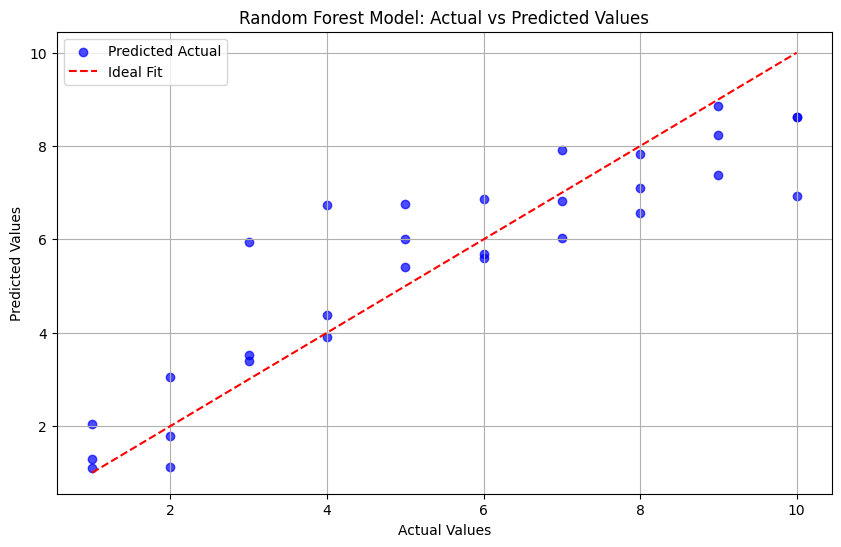

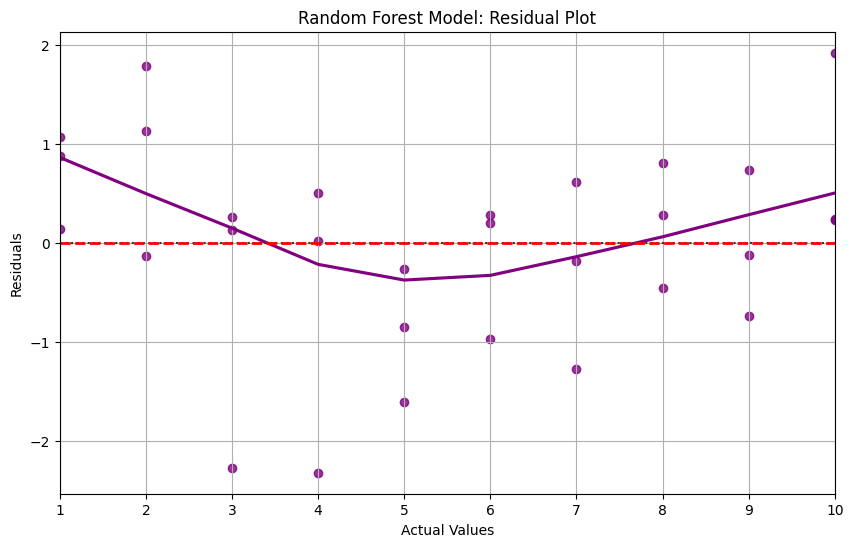

In [22]:
# Step 1: Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import joblib
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Upload the CSV File
uploaded = files.upload()

# Load the uploaded CSV file into a DataFrame
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# Step 3: Add Original Index for Traceability
df['Original_Index'] = df.index

# Step 4: Preprocessing the Data
# Check for missing values and fill them (if necessary)
if df.isnull().sum().sum() > 0:
    print("Missing values detected. Filling with mean values.")
    df.fillna(df.mean(), inplace=True)

# Normalize specific columns (if required)
scaler = MinMaxScaler()
columns_to_scale = ['Adjusted Similarity', 'Words', 'Unique_Words', 'Stop_Words', 'Non_Stop_Words', 'Sentences', 'Long_Words']
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

# Define Features and Target
features = ['Words', 'Unique_Words', 'Stop_Words', 'Non_Stop_Words', 'Sentences', 'Long_Words', 'Adjusted Similarity']
target = 'Rating'

X = df[features]
y = df[target]

# Step 5: Split the Dataset
# Use 150 rows for training and testing; 20 rows for unseen test data
X_train_test, X_unseen, y_train_test, y_unseen = train_test_split(
    X, y, test_size=20/170, random_state=42, shuffle=False
)
X_train, X_test, y_train, y_test = train_test_split(
    X_train_test, y_train_test, test_size=0.2, random_state=42, shuffle=False
)

# Map indices back to original dataset
train_indices = X_train.index
test_indices = X_test.index
unseen_indices = X_unseen.index

print("Training data indices:", train_indices)
print("Testing data indices:", test_indices)
print("Unseen data indices:", unseen_indices)

# Step 6: Train the Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit the model
rf_model.fit(X_train, y_train)

# Step 7: Predictions and Metrics
# Predict on training and validation/test data
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Predict on unseen test data
y_unseen_pred = rf_model.predict(X_unseen)

# Calculate metrics for validation/test set
rmse = mean_squared_error(y_test, y_test_pred) ** 0.5
r2 = r2_score(y_test, y_test_pred)

# Calculate metrics for unseen test set
new_rmse = mean_squared_error(y_unseen, y_unseen_pred) ** 0.5
new_r2 = r2_score(y_unseen, y_unseen_pred)

# Step 8: Display Randomized Rows with Predictions
training_results = pd.DataFrame({
    'Original Index': train_indices,
    'Actual': y_train,
    'Predicted': y_train_pred
}).sort_values(by='Original Index')

test_results = pd.DataFrame({
    'Original Index': test_indices,
    'Actual': y_test,
    'Predicted': y_test_pred
}).sort_values(by='Original Index')

unseen_results = pd.DataFrame({
    'Original Index': unseen_indices,
    'Actual': y_unseen,
    'Predicted': y_unseen_pred
}).sort_values(by='Original Index')

print("\n=== Training Data ===")
print(training_results)

print("\n=== Validation/Test Data ===")
print(test_results)

print("\n=== Unseen Test Data ===")
print(unseen_results)

# Step 9: Save Results and Model
# Save the model
joblib.dump(rf_model, 'random_forest_model.pkl')
print("\nModel saved as random_forest_model.pkl")

# Save the results to CSV files
training_results.to_csv('training_results.csv', index=False)
test_results.to_csv('test_results.csv', index=False)
unseen_results.to_csv('unseen_results.csv', index=False)

# Allow file download
files.download('training_results.csv')
files.download('test_results.csv')
files.download('unseen_results.csv')

# Optional: Download the model file
files.download('random_forest_model.pkl')

# Step 10: Display Metrics
print("\n=== Metrics ===")
print(f"Validation/Test RMSE: {rmse}")
print(f"Validation/Test R² Score: {r2}")
print(f"Unseen Test Set RMSE: {new_rmse}")
print(f"Unseen Test Set R² Score: {new_r2}")

# Step 11: Display Graphs
# Scatter Plot: Actual vs. Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.7, color='blue', label="Predicted Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label="Ideal Fit")
plt.title("Random Forest Model: Actual vs Predicted Values")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()
plt.grid(True)
plt.show()

# Residual Plot: Errors
residuals_rf = y_test - y_test_pred
plt.figure(figsize=(10, 6))
sns.residplot(x=y_test, y=residuals_rf, lowess=True, color="purple")
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title("Random Forest Model: Residual Plot")
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.grid(True)
plt.show()



Saving DataLatest.csv to DataLatest (18).csv
Training data indices: Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       110, 111, 112, 113, 114, 115, 116, 117, 118, 119],
      dtype='int64', length=120)
Testing data indices: Index([120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133,
       134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147,
       148, 149],
      dtype='int64')
Unseen data indices: Index([150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163,
       164, 165, 166, 167, 168, 169],
      dtype='int64')

=== Training Data ===
     Original Index  Actual  Predicted
0                 0       1   1.683254
1                 1       2   2.653953
2                 2       3   3.348385
3                 3       4   4.427623
4                 4       5   5.581632
..              ...     ...        ...
115             115       6   4.149115
116             116       7   5.415437
117             117       8

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== Metrics ===
Validation/Test RMSE: 1.5962405958555856
Validation/Test R² Score: 0.6911534497142551
Validation/Test MAE: 1.3520153799316916
Unseen Test Set RMSE: 0.994297219875282
Unseen Test Set R² Score: 0.8801664289149437
Unseen Test Set MAE: 0.8838256252535232


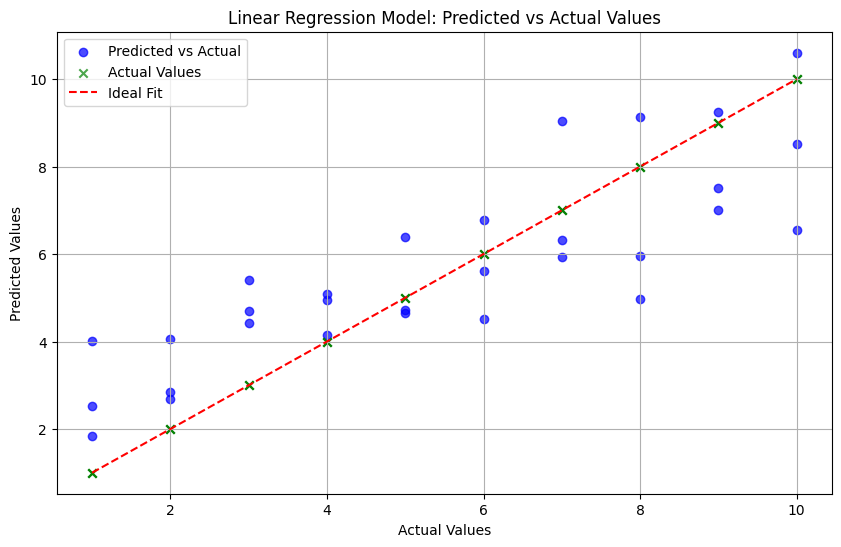

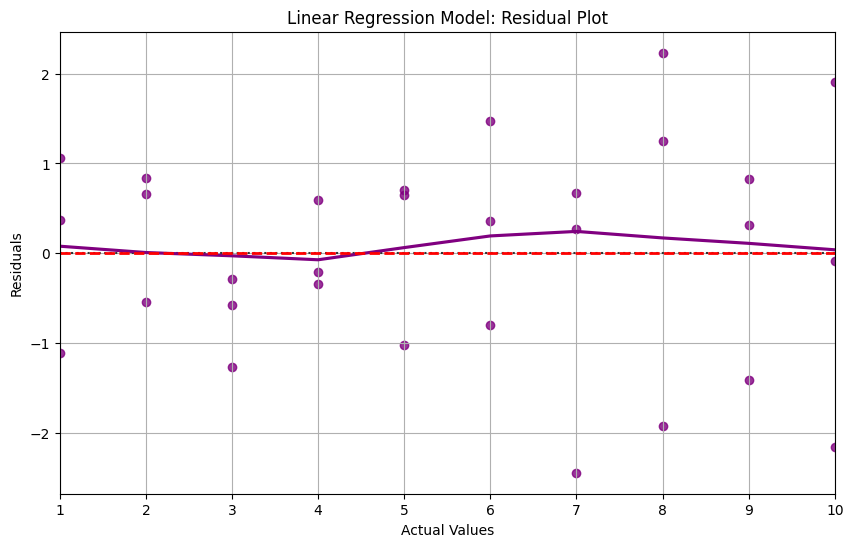

In [23]:
# Step 1: Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
import joblib
from google.colab import files

# Step 2: Upload the CSV File
uploaded = files.upload()

# Load the uploaded CSV file into a DataFrame
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# Step 3: Add Original Index for Traceability
df['Original_Index'] = df.index

# Step 4: Preprocessing the Data
# Check for missing values and fill them (if necessary)
if df.isnull().sum().sum() > 0:
    print("Missing values detected. Filling with mean values.")
    df.fillna(df.mean(), inplace=True)

# Normalize specific columns (if required)
scaler = MinMaxScaler()
columns_to_scale = ['Adjusted Similarity', 'Words', 'Unique_Words', 'Stop_Words', 'Non_Stop_Words', 'Sentences', 'Long_Words']
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

# Define Features and Target
features = ['Words', 'Unique_Words', 'Stop_Words', 'Non_Stop_Words', 'Sentences', 'Long_Words', 'Adjusted Similarity']
target = 'Rating'

X = df[features]
y = df[target]

# Step 5: Split the Dataset
X_train_test, X_unseen, y_train_test, y_unseen = train_test_split(
    X, y, test_size=20/170, random_state=42, shuffle=False
)
X_train, X_test, y_train, y_test = train_test_split(
    X_train_test, y_train_test, test_size=0.2, random_state=42, shuffle=False
)

# Map indices back to original dataset
train_indices = X_train.index
test_indices = X_test.index
unseen_indices = X_unseen.index

print("Training data indices:", train_indices)
print("Testing data indices:", test_indices)
print("Unseen data indices:", unseen_indices)

# Step 6: Train the Linear Regression Model
lr_model = LinearRegression()

# Fit the model
lr_model.fit(X_train, y_train)

# Step 7: Predictions and Metrics
# Predict on training and validation/test data
y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

# Predict on unseen test data
y_unseen_pred = lr_model.predict(X_unseen)

# Calculate metrics for validation/test set
rmse = mean_squared_error(y_test, y_test_pred) ** 0.5
r2 = r2_score(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)

# Calculate metrics for unseen test set
new_rmse = mean_squared_error(y_unseen, y_unseen_pred) ** 0.5
new_r2 = r2_score(y_unseen, y_unseen_pred)
new_mae = mean_absolute_error(y_unseen, y_unseen_pred)

# Step 8: Display Randomized Rows with Predictions
training_results = pd.DataFrame({
    'Original Index': train_indices,
    'Actual': y_train,
    'Predicted': y_train_pred
}).sort_values(by='Original Index')

test_results = pd.DataFrame({
    'Original Index': test_indices,
    'Actual': y_test,
    'Predicted': y_test_pred
}).sort_values(by='Original Index')

unseen_results = pd.DataFrame({
    'Original Index': unseen_indices,
    'Actual': y_unseen,
    'Predicted': y_unseen_pred
}).sort_values(by='Original Index')

print("\n=== Training Data ===")
print(training_results)

print("\n=== Validation/Test Data ===")
print(test_results)

print("\n=== Unseen Test Data ===")
print(unseen_results)

# Step 9: Save Results and Model
joblib.dump(lr_model, 'linear_regression_model.pkl')
print("\nModel saved as linear_regression_model.pkl")

training_results.to_csv('training_results.csv', index=False)
test_results.to_csv('test_results.csv', index=False)
unseen_results.to_csv('unseen_results.csv', index=False)

files.download('training_results.csv')
files.download('test_results.csv')
files.download('unseen_results.csv')
files.download('linear_regression_model.pkl')

# Step 10: Display Metrics
print("\n=== Metrics ===")
print(f"Validation/Test RMSE: {rmse}")
print(f"Validation/Test R² Score: {r2}")
print(f"Validation/Test MAE: {mae}")

print(f"Unseen Test Set RMSE: {new_rmse}")
print(f"Unseen Test Set R² Score: {new_r2}")
print(f"Unseen Test Set MAE: {new_mae}")

# Step 10: Display Graphs
# 1. Predicted vs Actual Values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.7, color='blue', label="Predicted vs Actual", marker='o')
plt.scatter(y_test, y_test, alpha=0.7, color='green', label="Actual Values", marker='x')

# Plot ideal fit line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label="Ideal Fit")

# Add labels and legend
plt.title("Linear Regression Model: Predicted vs Actual Values")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()
plt.grid(True)
plt.show()

# 2. Residual Plot: Errors
residuals_lr = y_test - y_test_pred
plt.figure(figsize=(10, 6))
sns.residplot(x=y_test, y=residuals_lr, lowess=True, color="purple")
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title("Linear Regression Model: Residual Plot")
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.grid(True)
plt.show()
